In [25]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [26]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [28]:
class discriminator(nn.Module):
  def __init__(self):
    super().__init__()
    self.feature = nn.Sequential(
        nn.Conv2d(1,32,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2),
        nn.Conv2d(32,64,kernel_size=3,stride=1,padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.Conv2d(64,128,kernel_size=3,stride=1,padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128*7*7,1024),
        nn.ReLU(),
        nn.Linear(1024,1),
        nn.Sigmoid()
    )

  def forward(self,out):
    out = self.feature(out)
    out = self.classifier(out)
    return out




In [29]:
class generator(nn.Module):
  def __init__(self):
   super().__init__()
   self.projection = nn.Sequential(
       nn.Linear(100,128*7*7), #100->128*7*7
       nn.ReLU(),
       nn.Unflatten(1,(128,7,7))
   )
   self.feature = nn.Sequential(
    nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 7→14
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),   # 14→28
    nn.Tanh()
   )

  def forward(self,out):
   out = self.projection(out)
   out = self.feature(out)
   return out



In [30]:
g = generator().to(device)
d = discriminator().to(device)
noise = torch.randn(32,100).to(device)
fake = g(noise)
print(fake.shape)
out = d(fake)
print(out.shape)


torch.Size([32, 1, 28, 28])
torch.Size([32, 1])


In [31]:
lr = 0.0002
epochs=150
dataloader = DataLoader(train_data,batch_size=32,shuffle=True)
loss = nn.BCELoss()
optimiser_d = torch.optim.Adam(d.parameters(),lr)
optimiser_g = torch.optim.Adam(g.parameters(),lr)

In [32]:
for epoch in range(epochs):
    for batch_idx, (real_images, _) in enumerate(dataloader):

        # Step 1: Train Discriminator

        # - get real images, label them 1
        images = real_images.to(device)
        real_labels = torch.ones(images.size(0), 1).to(device) * 0.9 # smooth labeling

        # - generate fake images, label them 0
        noise = torch.randn(images.size(0), 100).to(device)
        fake_labels = torch.zeros(noise.size(0), 1).to(device)

        # - compute discriminator loss on both
        loss_real = loss(d(images),real_labels)
        fake_images = g(noise)
        loss_fake = loss(d(fake_images.detach()),fake_labels)
        loss_d = loss_real + loss_fake

        # - update discriminator weights
        optimiser_d.zero_grad()
        loss_d.backward()
        optimiser_d.step()

        # Step 2: Train Generator

        # - generate fake images
        noise = torch.randn(images.size(0), 100).to(device)

        # - pass through discriminator
        fake_images = g(noise)

        # - loss = how well did it fool discriminator
        loss_g=-torch.mean(torch.log(d(fake_images)+1e-8))

        # - update generator weights
        optimiser_g.zero_grad()
        loss_g.backward()
        optimiser_g.step()
        if batch_idx % 100 == 0:
            print(f"Epoch [{epoch}/{epochs}] Batch {batch_idx} | Loss D: {loss_d.item():.4f} | Loss G: {loss_g.item():.4f}")

Epoch [0/150] Batch 0 | Loss D: 1.3962 | Loss G: 4.8830
Epoch [0/150] Batch 100 | Loss D: 0.3274 | Loss G: 7.5400
Epoch [0/150] Batch 200 | Loss D: 0.3291 | Loss G: 6.4081
Epoch [0/150] Batch 300 | Loss D: 0.4970 | Loss G: 4.4499
Epoch [0/150] Batch 400 | Loss D: 0.4277 | Loss G: 4.6950
Epoch [0/150] Batch 500 | Loss D: 0.3535 | Loss G: 5.0480
Epoch [0/150] Batch 600 | Loss D: 0.3480 | Loss G: 6.8047
Epoch [0/150] Batch 700 | Loss D: 0.3380 | Loss G: 9.1123
Epoch [0/150] Batch 800 | Loss D: 0.3992 | Loss G: 4.5416
Epoch [0/150] Batch 900 | Loss D: 0.4406 | Loss G: 4.1574
Epoch [0/150] Batch 1000 | Loss D: 0.5722 | Loss G: 4.1941
Epoch [0/150] Batch 1100 | Loss D: 0.3641 | Loss G: 4.4864
Epoch [0/150] Batch 1200 | Loss D: 0.3506 | Loss G: 5.6448
Epoch [0/150] Batch 1300 | Loss D: 0.3574 | Loss G: 6.8579
Epoch [0/150] Batch 1400 | Loss D: 0.3792 | Loss G: 4.9829
Epoch [0/150] Batch 1500 | Loss D: 0.3510 | Loss G: 4.5364
Epoch [0/150] Batch 1600 | Loss D: 0.3488 | Loss G: 7.0026
Epoch [0/

KeyboardInterrupt: 

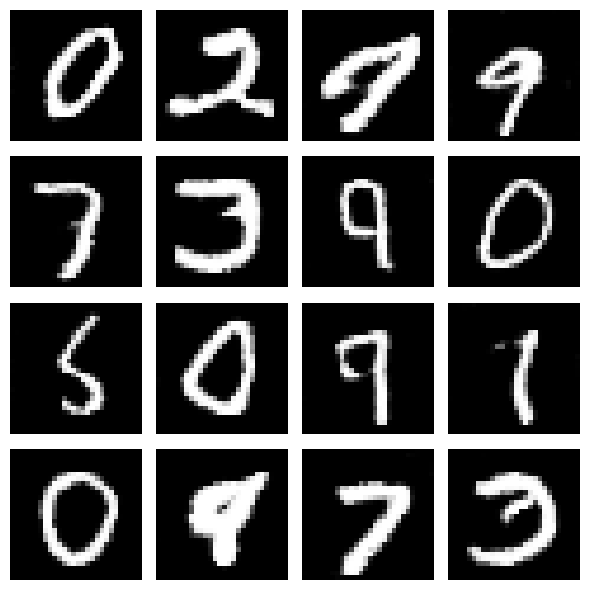

In [33]:
import matplotlib.pyplot as plt

g.eval()
with torch.no_grad():
    noise = torch.randn(16, 100).to(device)
    fake = g(noise)
    fake = fake.cpu().squeeze()

fig, axes = plt.subplots(4, 4, figsize=(6,6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(fake[i], cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()